# Phase 3: Adaptive Fusion with an Extended Kalman Filter

In Phase 2, we corrected the PINN's drifting prediction by blending it with vision observations using a fixed ratio — 70% vision, 30% PINN, always. That works, but it's a blunt instrument: it trusts vision exactly the same amount whether the observation is crystal clear or badly noisy, and it trusts the PINN the same amount whether its prediction is fresh and reliable or has drifted far off course.

Real orbit-determination systems don't do this. They use a **Kalman Filter** — an algorithm that keeps track of how *uncertain* each estimate currently is, and automatically leans more heavily on whichever source (the physics model or the observation) is more trustworthy at that moment. When the physics prediction has just been "reset" by a good observation, the filter trusts it more. When several time steps have passed without a fresh observation, physics-based uncertainty grows, and the filter leans harder on the next observation to correct course.

Because our orbital dynamics are **nonlinear** (gravity doesn't scale linearly with distance), we need a variant called the **Extended Kalman Filter (EKF)**, which approximates the nonlinear system with a linear one at each step before applying the same core logic.

In this notebook, we'll:
1. Build the EKF's physics-based "prediction" step, using the same (drag-unaware) gravity model our PINN was built on.
2. Build its "correction" step, using the vision model's position observations from Phase 2.
3. Run the filter across the full disturbed orbit, letting it adaptively balance trust between prediction and observation.
4. Compare it against the true orbit, the PINN-only prediction, and our original fixed-ratio blended correction — to see whether principled, uncertainty-aware fusion actually beats the simple blend.

   ![The predict/correct cycle](../images/kalman_cycle.png)

## Why "Extended"?

A standard Kalman Filter assumes the system behaves **linearly** — meaning if you double the input, you double the output, with no curves or surprises. Gravity doesn't work that way: the pull on our satellite depends on $\frac{1}{r^2}$, the inverse square of its distance from the central body. That's a curved, nonlinear relationship, and a plain Kalman Filter can't handle it directly.

The **Extended** Kalman Filter's trick is simple: at every single time step, it temporarily pretends the nonlinear system is "flat" — approximating the curve with a straight line, just for that one small step. This approximation, called **linearization**, is done using a **Jacobian matrix**: essentially, a table of "if this input changes a little, how much does each output change?" derivatives, calculated fresh at the satellite's current position.

As long as each individual time step is small, this flat approximation is accurate enough — the same logic behind why a tiny piece of a curve looks almost like a straight line if you zoom in far enough. Calculating this Jacobian by hand for our gravity equations would mean a page of calculus, but we'll let **PyTorch's automatic differentiation do it for us** — the same tool that powered our PINN's physics loss back in Phase 1.


   ![Zooming in on a curve makes it look linear](../images/linearization_concept.png)

## Step 1: The Process Model (Predict Step)

The "predict" half of our filter needs a function that steps the satellite's state `[x, y, vx, vy]` forward by a small time increment, using gravity alone — the same physics our PINN was built on, still unaware of drag.

We'll use a small Runge-Kutta (RK4) step rather than simple Euler integration, since RK4 stays accurate even with a relatively large step size, keeping our filter efficient.

Then — instead of hand-deriving the Jacobian (the "how sensitive is each output to each input" matrix needed for linearization), we'll let **PyTorch's automatic differentiation compute it directly** from the function itself. This is the same tool that powered our PINN's physics loss, now repurposed for a completely different kind of problem.

In [18]:
# Core numerical arrays and math operations
import numpy as np

# Neural network framework — needed for autograd's Jacobian computation
import torch
import torch.nn as nn
from torch.autograd.functional import jacobian

# Static plots for the final comparison visualizations
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [19]:
from torch.autograd.functional import jacobian

def state_transition(state, dt, GM=1.0):
    """
    Steps the state [x, y, vx, vy] forward by dt using gravity-only physics
    (no drag) — an RK4 step for accuracy.
    """
    def dynamics(s):
        x, y, vx, vy = s[0], s[1], s[2], s[3]
        r = torch.sqrt(x**2 + y**2 + 1e-8)
        ax = -GM * x / r**3
        ay = -GM * y / r**3
        return torch.stack([vx, vy, ax, ay])

    k1 = dynamics(state)
    k2 = dynamics(state + dt / 2 * k1)
    k3 = dynamics(state + dt / 2 * k2)
    k4 = dynamics(state + dt * k3)

    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


# Quick sanity check: compute the Jacobian (F matrix) at our satellite's starting state
test_state = torch.tensor([1.0, 0.0, 0.0, 0.8])
test_dt = 0.02
F_sample = jacobian(lambda s: state_transition(s, test_dt), test_state)
print("Sample state-transition Jacobian (F matrix):")
print(F_sample)

Sample state-transition Jacobian (F matrix):
tensor([[ 1.0004e+00,  3.2000e-06,  2.0003e-02,  3.2001e-08],
        [ 3.2004e-06,  9.9980e-01,  3.2001e-08,  1.9999e-02],
        [ 4.0003e-02,  4.8001e-04,  1.0004e+00,  6.4003e-06],
        [ 4.8010e-04, -1.9995e-02,  6.4008e-06,  9.9980e-01]])


## Recreating the Phase 1 & 2 Baseline

Since this is a separate notebook with its own fresh kernel, we need to reload the trained PINN and CNN detector, and regenerate the disturbed orbit and vision observations — the same steps from Phases 1 and 2, just re-run here so this notebook is self-contained.

In [20]:
class PINN(nn.Module):
    def __init__(self, hidden_dim=64, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)


pinn = PINN(hidden_dim=64, n_hidden_layers=4).to(device)
pinn.load_state_dict(torch.load("pinn_weights.pth", map_location=device))
pinn.eval()

GM = 1.0
initial_state = [1.0, 0.0, 0.0, 0.8]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

t_test = torch.tensor(t_eval, dtype=torch.float32, device=device).reshape(-1, 1)
with torch.no_grad():
    r_pred = pinn(t_test).cpu().numpy()
x_pinn, y_pinn = r_pred[:, 0], r_pred[:, 1]

print("PINN reloaded.")

PINN reloaded.


In [21]:
from scipy.integrate import solve_ivp

k_drag = 0.003

def disturbed_dynamics(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    v = np.sqrt(vx**2 + vy**2)
    ax = -GM * x / r**3 - k_drag * v * vx
    ay = -GM * y / r**3 - k_drag * v * vy
    return [vx, vy, ax, ay]

solution_disturbed = solve_ivp(
    disturbed_dynamics, t_span, initial_state, t_eval=t_eval,
    method="DOP853", rtol=1e-10, atol=1e-10
)
x_disturbed, y_disturbed = solution_disturbed.y[0], solution_disturbed.y[1]

print("Disturbed orbit regenerated.")

Disturbed orbit regenerated.


In [22]:
class SatelliteDetector(nn.Module):
    def __init__(self, image_size=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        flattened_size = 32 * (image_size // 4) * (image_size // 4)
        self.fc = nn.Sequential(nn.Linear(flattened_size, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, x):
        x = self.conv(x)
        x = x.flatten(start_dim=1)
        return self.fc(x)


image_size = 64
world_extent = 1.5

def world_to_pixel(x, y, image_size=image_size, extent=world_extent):
    px = ((x + extent) / (2 * extent)) * image_size
    py = ((extent - y) / (2 * extent)) * image_size
    return px, py

def pixel_to_world(px, py, image_size=image_size, extent=world_extent):
    x = (px / image_size) * (2 * extent) - extent
    y = extent - (py / image_size) * (2 * extent)
    return x, y

def generate_telescope_image(x, y, image_size=image_size, noise_level=0.05, dot_sigma=1.2):
    px, py = world_to_pixel(x, y, image_size)
    xx, yy = np.meshgrid(np.arange(image_size), np.arange(image_size))
    image = np.exp(-((xx - px)**2 + (yy - py)**2) / (2 * dot_sigma**2))
    image += np.random.normal(0, noise_level, size=image.shape)
    return np.clip(image, 0, 1)


detector = SatelliteDetector(image_size=image_size).to(device)
detector.load_state_dict(torch.load("detector_weights.pth", map_location=device))
detector.eval()

vision_x, vision_y = [], []
with torch.no_grad():
    for i in range(len(x_disturbed)):
        img = generate_telescope_image(x_disturbed[i], y_disturbed[i])
        img_t = torch.tensor(img, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
        px_pred, py_pred = detector(img_t)[0].cpu().numpy()
        x_obs, y_obs = pixel_to_world(px_pred, py_pred)
        vision_x.append(x_obs)
        vision_y.append(y_obs)

vision_x, vision_y = np.array(vision_x), np.array(vision_y)
print("Vision observations regenerated.")

Vision observations regenerated.


In [23]:
alpha = 0.7
x_corrected = (1 - alpha) * x_pinn + alpha * vision_x
y_corrected = (1 - alpha) * y_pinn + alpha * vision_y
print("Simple-blend correction recreated.")

Simple-blend correction recreated.


## Step 2: The Measurement Model and Noise Parameters

Our vision model observes position directly — it doesn't see velocity. So our **measurement model** just picks out the `(x, y)` part of the state:

$$
H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}
$$

We also need two noise parameters, and this is where the filter's "intelligence" actually comes from:

- **Measurement noise ($R$)** — how much we expect vision observations to wobble around the truth. Rather than guessing, we can measure this directly: we already know the true disturbed orbit, so we can compute exactly how far off our vision observations typically were.
- **Process noise ($Q$)** — how much we *don't* trust our physics-only prediction between observations. Since our model doesn't know about drag, and drag acts on velocity, we'll set this larger for the velocity components than the position components.

These two numbers are the actual "knobs" of the filter — together they determine the Kalman gain, which decides how much to trust each source at every single step.

In [24]:
# Measurement model: vision observes (x, y) directly, not velocity
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

# Measurement noise: estimated directly from how far our vision observations
# actually deviated from the true disturbed orbit
vision_error_x = vision_x - x_disturbed
vision_error_y = vision_y - y_disturbed
R = np.diag([np.var(vision_error_x), np.var(vision_error_y)])

# Process noise: reflects how much we don't trust the physics-only prediction
# (it doesn't know about drag, which acts on velocity directly)
Q = np.diag([1e-5, 1e-5, 1e-3, 1e-3])

print("R (measurement noise):\n", R)
print("Q (process noise):\n", Q)

R (measurement noise):
 [[0.00023928 0.        ]
 [0.         0.00023294]]
Q (process noise):
 [[1.e-05 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e-05 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e-03 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e-03]]


## Step 3: Running the Filter

Now we run the predict/correct cycle across every time step in our simulation:

1. **Predict** — step the state forward using our gravity-only physics model, and compute the Jacobian to propagate uncertainty forward too.
2. **Correct** — compare the prediction to this time step's vision observation, compute the Kalman gain (how much to trust the observation vs. the prediction), and blend accordingly.

Unlike Phase 2's fixed 70/30 blend, this ratio is recalculated from scratch at every single step, based on the filter's actual current uncertainty.

In [25]:
# Initial state and covariance: we trust the known starting condition almost exactly
state_est = np.array(initial_state, dtype=np.float64)
P = np.eye(4) * 1e-6

x_ekf = np.zeros(len(t_eval))
y_ekf = np.zeros(len(t_eval))
x_ekf[0], y_ekf[0] = state_est[0], state_est[1]

for i in range(1, len(t_eval)):
    dt = t_eval[i] - t_eval[i - 1]

    # --- Predict ---
    state_tensor = torch.tensor(state_est, dtype=torch.float32)
    state_pred_tensor = state_transition(state_tensor, dt, GM=GM)
    F_tensor = jacobian(lambda s: state_transition(s, dt, GM=GM), state_tensor)

    state_pred = state_pred_tensor.detach().numpy()
    F = F_tensor.detach().numpy()

    P_pred = F @ P @ F.T + Q

    # --- Correct using this time step's vision observation ---
    z = np.array([vision_x[i], vision_y[i]])
    y_residual = z - H @ state_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    state_est = state_pred + K @ y_residual
    P = (np.eye(4) - K @ H) @ P_pred

    x_ekf[i], y_ekf[i] = state_est[0], state_est[1]

print("EKF run complete.")

EKF run complete.


## Step 4: Does the EKF Actually Beat the Simple Blend?

Time to compare all four trajectories: the true (disturbed) orbit, the PINN's physics-only prediction, our original fixed 70/30 blend from Phase 2, and this new adaptive Kalman Filter estimate. If the EKF is doing its job, it should track the true orbit at least as closely as the simple blend — ideally more closely, since it's reacting to actual uncertainty rather than a fixed guess.

Average PINN-only error:       1.1252
Average simple-blend error:    0.3379
Average EKF error:             0.0113


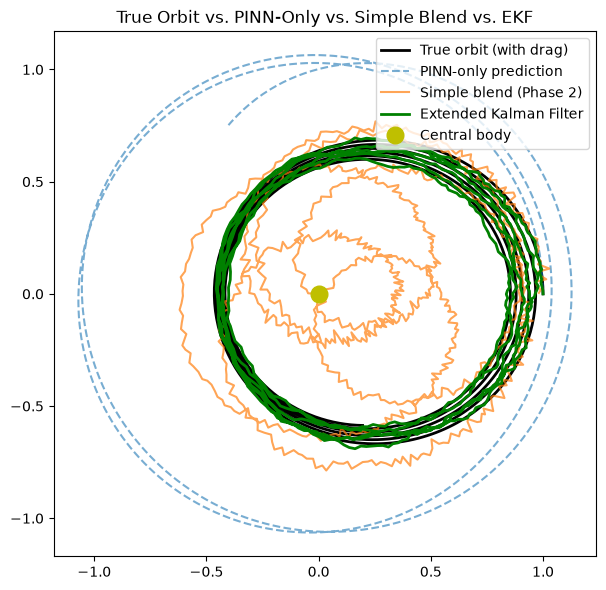

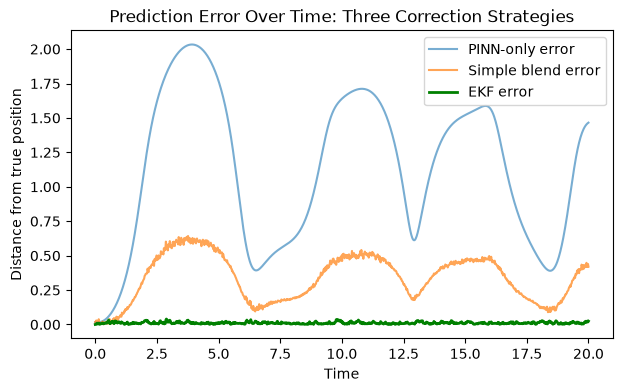

In [26]:
# --- Compute errors for all three approaches ---
error_pinn_only = np.sqrt((x_pinn - x_disturbed)**2 + (y_pinn - y_disturbed)**2)
error_simple_blend = np.sqrt((x_corrected - x_disturbed)**2 + (y_corrected - y_disturbed)**2)
error_ekf = np.sqrt((x_ekf - x_disturbed)**2 + (y_ekf - y_disturbed)**2)

print(f"Average PINN-only error:       {error_pinn_only.mean():.4f}")
print(f"Average simple-blend error:    {error_simple_blend.mean():.4f}")
print(f"Average EKF error:             {error_ekf.mean():.4f}")

# --- Trajectory comparison ---
plt.figure(figsize=(7, 7))
plt.plot(x_disturbed, y_disturbed, label="True orbit (with drag)", linewidth=2, color="black")
plt.plot(x_pinn, y_pinn, '--', label="PINN-only prediction", alpha=0.6)
plt.plot(x_corrected, y_corrected, label="Simple blend (Phase 2)", alpha=0.7)
plt.plot(x_ekf, y_ekf, label="Extended Kalman Filter", linewidth=2, color="green")
plt.plot(0, 0, "yo", markersize=12, label="Central body")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right")
plt.title("True Orbit vs. PINN-Only vs. Simple Blend vs. EKF")
plt.show()

# --- Error over time ---
plt.figure(figsize=(7, 4))
plt.plot(t_eval, error_pinn_only, label="PINN-only error", alpha=0.6)
plt.plot(t_eval, error_simple_blend, label="Simple blend error", alpha=0.7)
plt.plot(t_eval, error_ekf, label="EKF error", linewidth=2, color="green")
plt.xlabel("Time")
plt.ylabel("Distance from true position")
plt.title("Prediction Error Over Time: Three Correction Strategies")
plt.legend()
plt.show()